In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
df=pd.read_csv("D:/EVELATE_LAS_INTERSHIP/Healthcare_NoShow_Prediction/data/appointments.csv")
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [27]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])

df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

In [28]:
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize() -
    df["ScheduledDay"].dt.normalize()
).dt.days

df["WaitingDays"].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

In [29]:
df = df[df["WaitingDays"] >= 0]

print(df.shape)

(110522, 15)


In [30]:
df["Weekday"] = df["AppointmentDay"].dt.day_name()

df["Weekday"].value_counts()

Weekday
Wednesday    25866
Tuesday      25638
Monday       22714
Friday       19019
Thursday     17246
Saturday        39
Name: count, dtype: int64

In [31]:
df["Month"] = df["AppointmentDay"].dt.month

df["Month"].value_counts()

Month
5    80836
6    26451
4     3235
Name: count, dtype: int64

In [32]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,18,35,60,120],
    labels=[
        "Child",
        "Young Adult",
        "Adult",
        "Senior"
    ],
    include_lowest=True
)

df["AgeGroup"].value_counts()

AgeGroup
Adult          37760
Child          28865
Young Adult    24135
Senior         19761
Name: count, dtype: int64

In [33]:
df["No-show"] = df["No-show"].map({
    "No":0,
    "Yes":1
})

df["No-show"].value_counts()

No-show
0    88208
1    22314
Name: count, dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


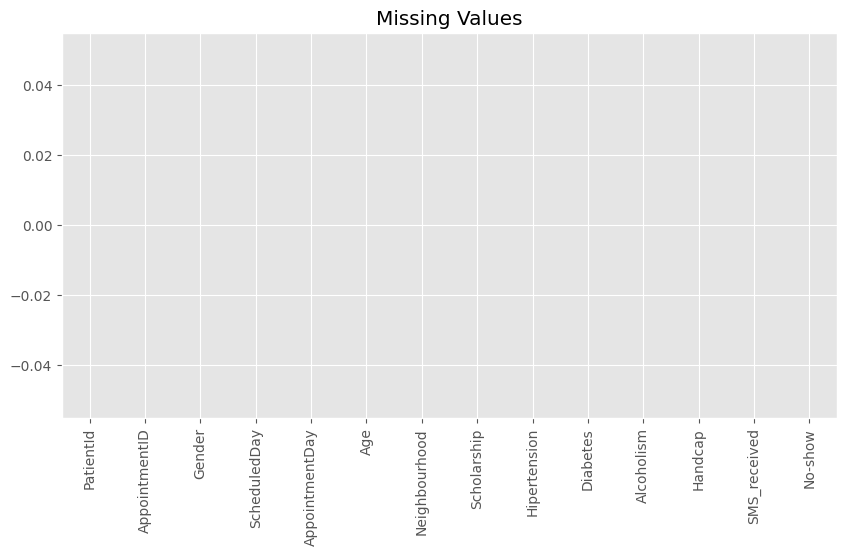

In [5]:
missing = df.isnull().sum()

print(missing)

missing.plot(
    kind="bar",
    figsize=(10,5),
    title="Missing Values"
)

plt.show()

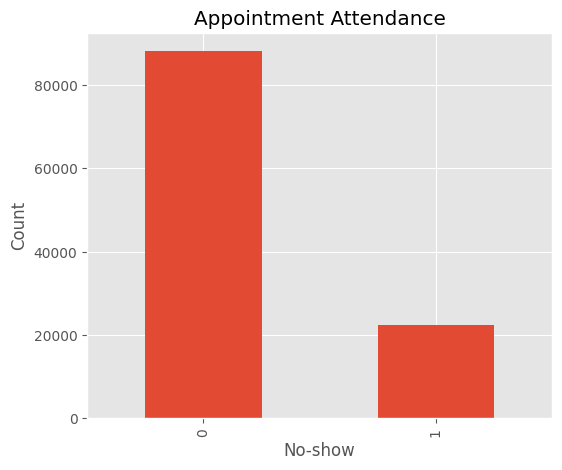

No-show
0    88208
1    22314
Name: count, dtype: int64


In [34]:
plt.figure(figsize=(6,5))

df["No-show"].value_counts().plot(
    kind="bar"
)

plt.title("Appointment Attendance")

plt.xlabel("No-show")

plt.ylabel("Count")

plt.show()

print(df["No-show"].value_counts())

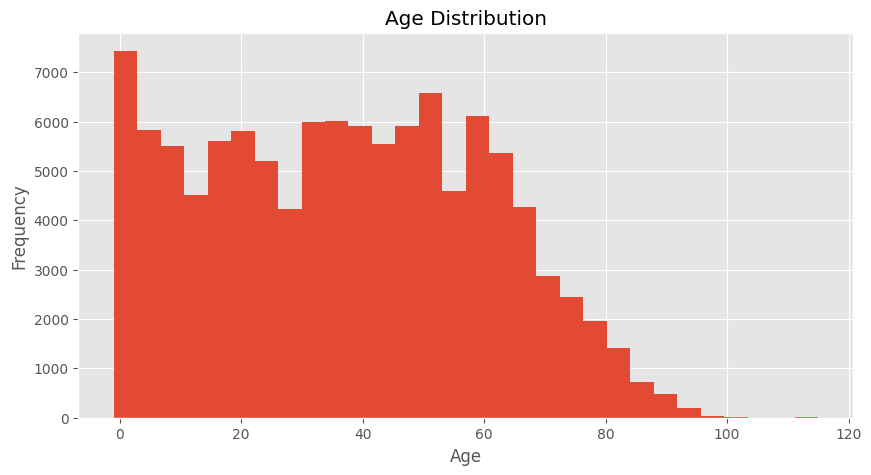

In [8]:
plt.figure(figsize=(10,5))

plt.hist(df["Age"], bins=30)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

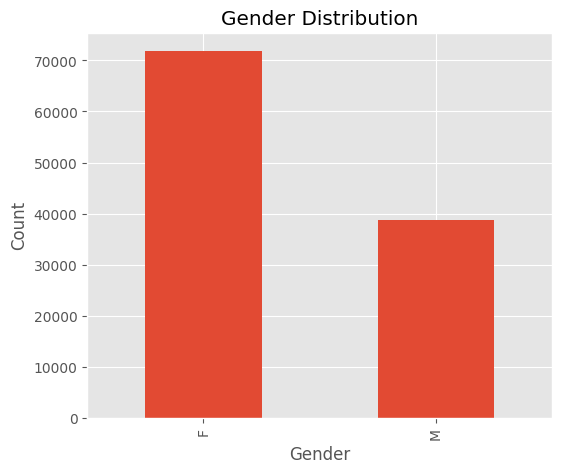

Gender
F    71837
M    38685
Name: count, dtype: int64


In [35]:
gender = df["Gender"].value_counts()

gender.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

print(gender)

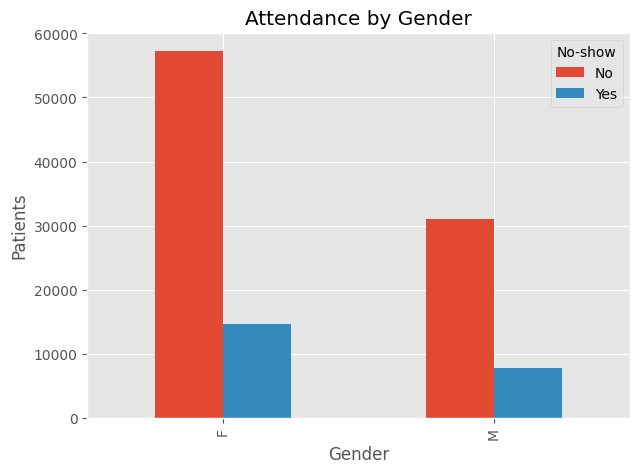

No-show,No,Yes
Gender,,
F,57246,14594
M,30962,7725


In [10]:
attendance_gender = pd.crosstab(
    df["Gender"],
    df["No-show"]
)

attendance_gender.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Attendance by Gender")

plt.ylabel("Patients")

plt.show()

attendance_gender

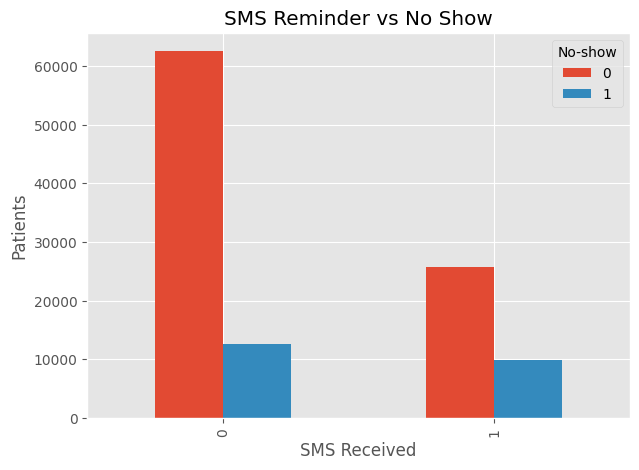

No-show,0,1
SMS_received,,
0,62510,12530
1,25698,9784


In [36]:
sms = pd.crosstab(
    df["SMS_received"],
    df["No-show"]
)

sms.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("SMS Reminder vs No Show")

plt.xlabel("SMS Received")

plt.ylabel("Patients")

plt.show()

sms

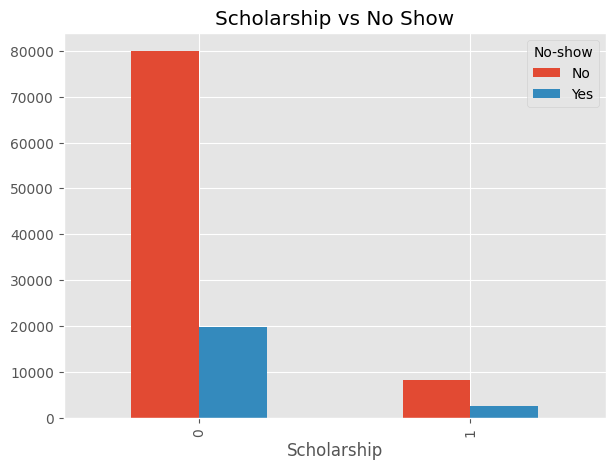

No-show,No,Yes
Scholarship,,
0,79925,19741
1,8283,2578


In [12]:
sch = pd.crosstab(
    df["Scholarship"],
    df["No-show"]
)

sch.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Scholarship vs No Show")

plt.show()

sch

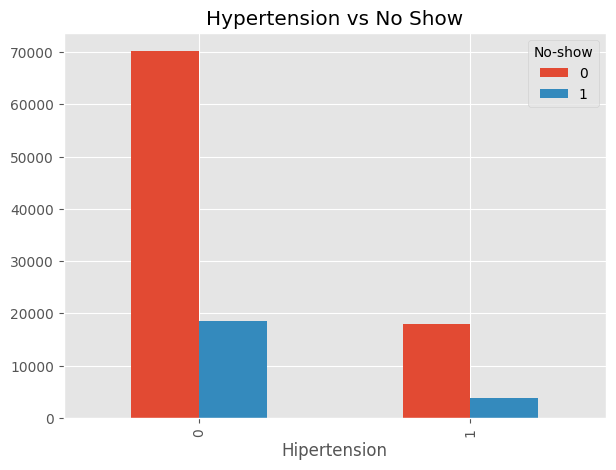

No-show,0,1
Hipertension,,
0,70179,18542
1,18029,3772


In [37]:
hyp = pd.crosstab(
    df["Hipertension"],
    df["No-show"]
)

hyp.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Hypertension vs No Show")

plt.show()

hyp

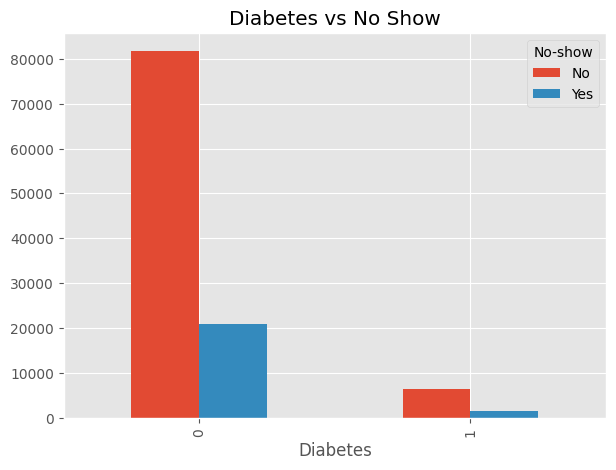

No-show,No,Yes
Diabetes,,
0,81695,20889
1,6513,1430


In [14]:
dia = pd.crosstab(
    df["Diabetes"],
    df["No-show"]
)

dia.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Diabetes vs No Show")

plt.show()

dia

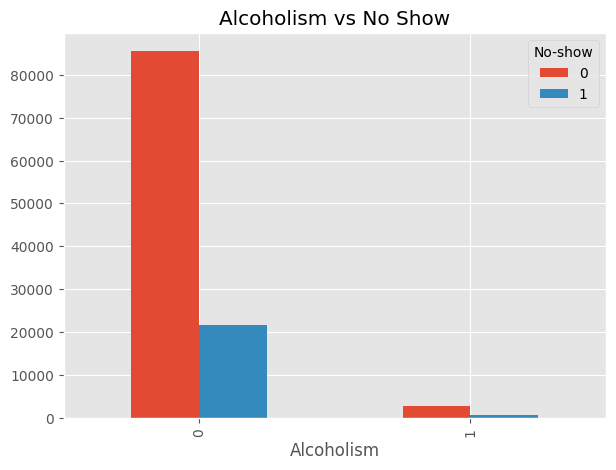

No-show,0,1
Alcoholism,,
0,85525,21637
1,2683,677


In [38]:
alc = pd.crosstab(
    df["Alcoholism"],
    df["No-show"]
)

alc.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Alcoholism vs No Show")

plt.show()

alc

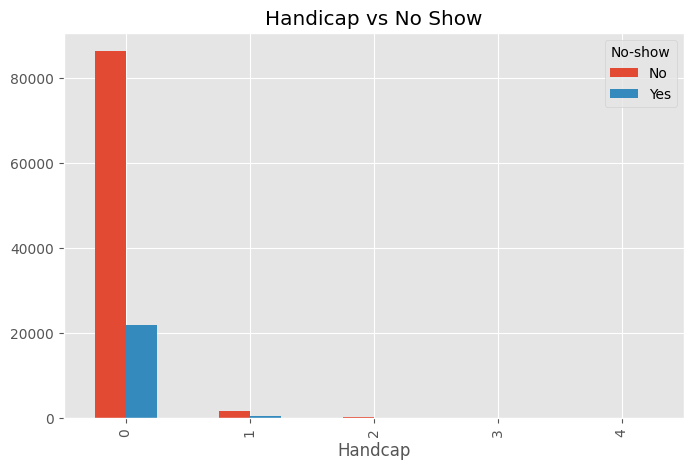

No-show,No,Yes
Handcap,,
0,86374,21912
1,1676,366
2,146,37
3,10,3
4,2,1


In [16]:
hand = pd.crosstab(
    df["Handcap"],
    df["No-show"]
)

hand.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Handicap vs No Show")

plt.show()

hand

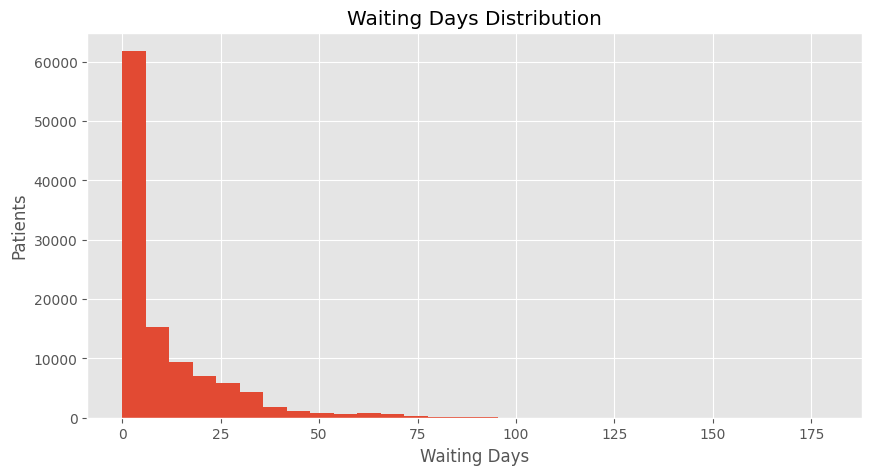

In [39]:
plt.figure(figsize=(10,5))

plt.hist(df["WaitingDays"], bins=30)

plt.title("Waiting Days Distribution")

plt.xlabel("Waiting Days")

plt.ylabel("Patients")

plt.show()

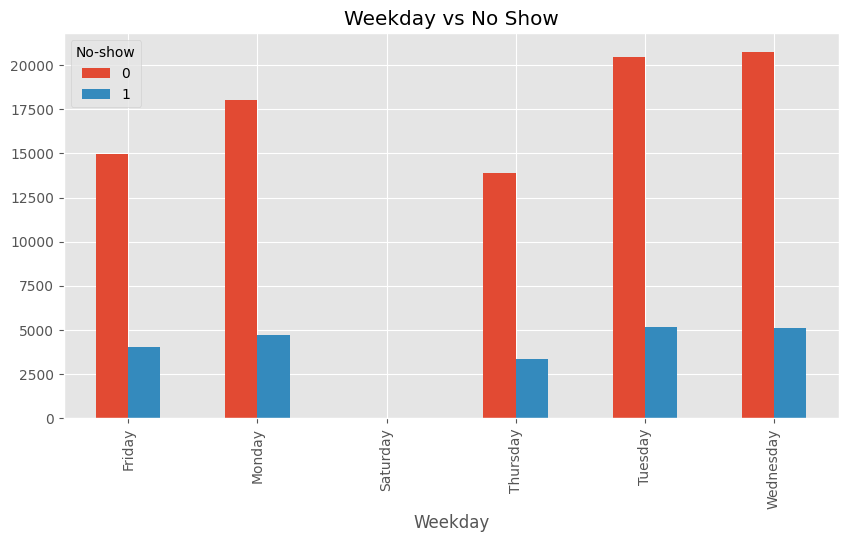

No-show,0,1
Weekday,,
Friday,14982,4037
Monday,18025,4689
Saturday,30,9
Thursday,13909,3337
Tuesday,20488,5150
Wednesday,20774,5092


In [40]:
weekday = pd.crosstab(
    df["Weekday"],
    df["No-show"]
)

weekday.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Weekday vs No Show")

plt.show()

weekday

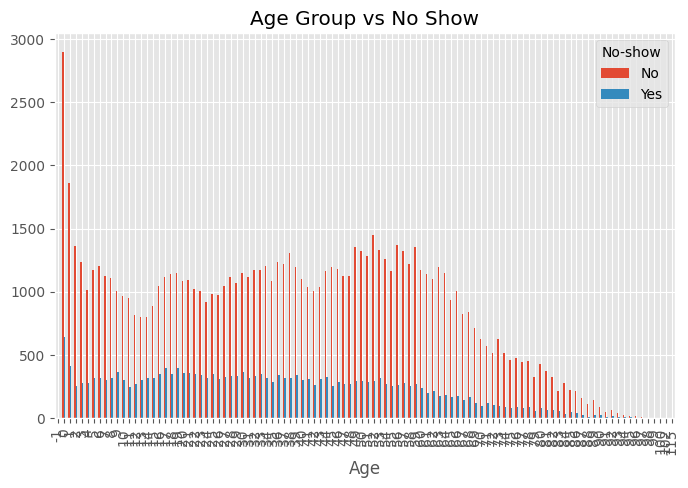

No-show,No,Yes
Age,,
-1,1,0
0,2900,639
1,1858,415
2,1366,252
3,1236,277
...,...,...
98,5,1
99,1,0
100,4,0


In [22]:
agegroup = pd.crosstab(
    df["Age"],
    df["No-show"]
)

agegroup.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Age Group vs No Show")

plt.show()

agegroup

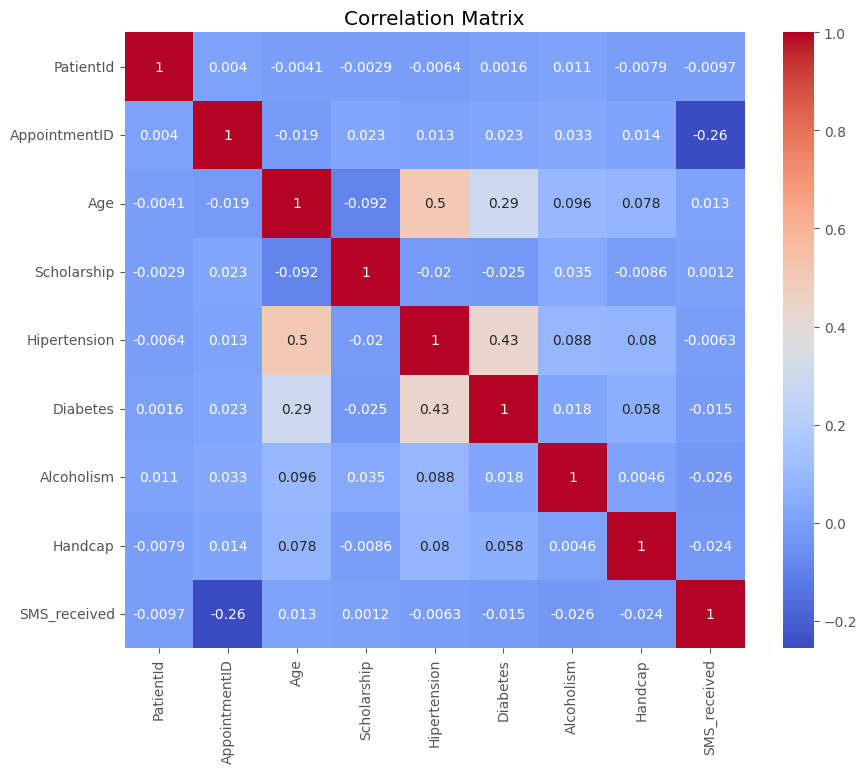

In [23]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

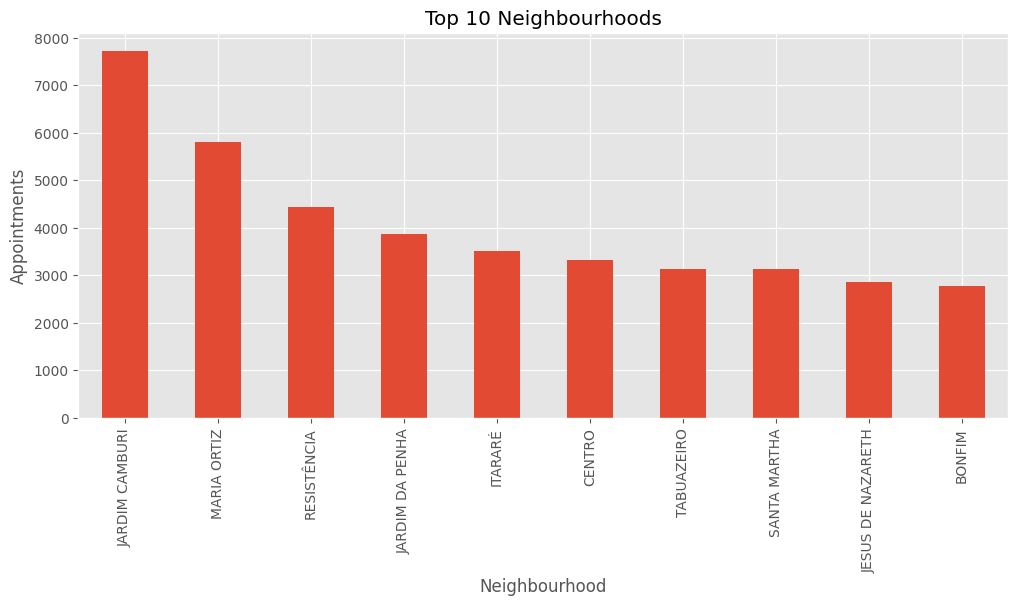

Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64

In [24]:
top = df["Neighbourhood"].value_counts().head(10)

top.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Neighbourhoods")

plt.xlabel("Neighbourhood")

plt.ylabel("Appointments")

plt.show()

top

In [25]:
rate = df["No-show"].value_counts(normalize=True) * 100

print("Attendance Percentage")

print(rate)

Attendance Percentage
No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


In [42]:
df.to_csv("eda_cleaned_appointments.csv", index=False)

print("cleaned_appointments.csv Saved Successfully!")

cleaned_appointments.csv Saved Successfully!


In [43]:
print("="*60)
print("Healthcare Appointment No-Show Prediction - EDA Summary")
print("="*60)

print("Total Appointments :", len(df))
print("Average Age :", round(df["Age"].mean(),2))
print("Average Waiting Days :", round(df["WaitingDays"].mean(),2))
print("Patients Attended :", (df["No-show"]==0).sum())
print("Patients Missed :", (df["No-show"]==1).sum())

print("="*60)

Healthcare Appointment No-Show Prediction - EDA Summary
Total Appointments : 110522
Average Age : 37.09
Average Waiting Days : 10.18
Patients Attended : 88208
Patients Missed : 22314
